In [11]:
import os
import glob
import gzip
import pickle

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LogNorm

import shapely.wkt as wkt
from shapely.geometry import Point, LineString, box
from shapely.ops import nearest_points
import lxml.etree as ET
# import network_io as nio
from itertools import combinations
import random
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import gc
import random
import pandas as pd
import gzip
import xml.etree.ElementTree as ET

import sys
sys.path.append('../')
import network_io as nio

## Abstract

In this notebook, we create subgraphs with capacity reduction in single roads. Depending on whether the flag "is_for_general_pst_roads" is set to True or False, we create subgraphs for general pst roads or pst roads in the inner districts.

In [12]:
is_for_general_pst_roads = False # True if we want to create subgraphs for general pst roads, False if we want to create subgraphs for pst roads in certain districts

result_df_name = 'dataset_1pct_cap_reduction_on_general_pst_roads' if is_for_general_pst_roads else 'dataset_1pct_cap_reduction_on_pst_roads_in_inner_districts'
# result_path = '../../../../../data/created_subgraphs/' + result_df_name + '.pt'

network_path = '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/general_pst_roads/paris_1pct_network.xml.gz' if is_for_general_pst_roads else '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts/paris_1pct_network.xml.gz'
path = 'pop_1pct_cap_reduction/cap_reduction_on_single_roads/general_pst_roads/' if is_for_general_pst_roads else 'pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts/'


In [13]:
districts_gdf = gpd.read_file("../../../../../data/visualisation/districts_paris.geojson")

base_output_links_no_policies = '../../../../../data/pop_1pct_simulations/pop_1pct_basecase/output_seed_1/'
base_network_no_policies = nio.read_network_data(base_output_links_no_policies)
base_network_no_policies.rename(columns={'link': 'id'}, inplace=True)

base_dir = '../../../../../data/pop_1pct_simulations/' + path
subdirs_pattern = os.path.join(base_dir, 'output_networks_*')
subdirs = list(set(glob.glob(subdirs_pattern)))
subdirs.sort()

In [14]:
base_network_no_policies.rename(columns={'capacity': 'capacity_base_case'}, inplace=True)
base_network_no_policies.rename(columns={'vol_car': 'vol_car_base_case'}, inplace=True)

In [15]:
# Parse nodes and edges
nodes_dict = nio.parse_nodes(network_path)
df_edges = nio.parse_edges(network_path, nodes_dict)
gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs='EPSG:2154')
gdf_edges_4326 = gdf_edges.to_crs(epsg=4326)

# Spatial join to find districts overlapping with each edge
gdf_edges_with_districts = gpd.sjoin(gdf_edges_4326, districts_gdf, how='left', op='intersects')

# Group by edge and aggregate the district names
gdf_edges_with_districts = gdf_edges_with_districts.groupby('id').agg({
    'from': 'first',
    'to': 'first',
    'length': 'first',
    'freespeed': 'first',
    'capacity': 'first',
    'permlanes': 'first',
    'oneway': 'first',
    'modes': 'first',
    'geometry': 'first',
    'c_ar': lambda x: list(x.dropna())
}).reset_index()

# Rename the aggregated column to 'district'
gdf_edges_with_districts.rename(columns={'c_ar': 'district'}, inplace=True)

# Convert freespeed and capacity to numeric values
gdf_edges_with_districts['freespeed'] = pd.to_numeric(gdf_edges_with_districts['freespeed'], errors='coerce')
gdf_edges_with_districts['capacity'] = pd.to_numeric(gdf_edges_with_districts['capacity'], errors='coerce')

gdf_edges_with_highway = gdf_edges_with_districts.merge(base_network_no_policies[['id', 'osm:way:highway', 'vol_car_base_case', 'capacity_base_case']], on='id', how='left')
gdf_edges_with_highway = gpd.GeoDataFrame(gdf_edges_with_highway, geometry='geometry', crs='EPSG:4326')

/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3448: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/pandas/core/reshape/merge.py:1203: RuntimeWarning: invalid value encountered in cast
  if not (lk == lk.astype(rk.dtype))[~np.isnan(lk)].all():



Top 50 primary roads:
Minimum length: 100m
District filter: 1-7


/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,id,osm:way:highway,vol_car_base_case,capacity_base_case,district,length,geometry
23199,599421,primary,231,3600.0,[1.0],494.256971,"LINESTRING (2.33335 48.86011, 2.33985 48.85899)"
13897,387167,primary,262,2400.0,[4.0],381.341189,"LINESTRING (2.34835 48.85873, 2.35015 48.86195)"
16478,450737,primary,183,2400.0,"[3.0, 10.0]",359.639835,"LINESTRING (2.36115 48.86814, 2.35637 48.86885)"
13590,379813,primary,219,3600.0,[5.0],353.696266,"LINESTRING (2.36095 48.84685, 2.35757 48.84912)"
13588,379811,primary,217,3600.0,[5.0],311.142981,"LINESTRING (2.36390 48.84484, 2.36095 48.84685)"
22676,587127,primary,212,2400.0,[1.0],308.089985,"LINESTRING (2.32538 48.86238, 2.32916 48.86118)"
2537,155459,primary,266,1200.0,[6.0],259.840921,"LINESTRING (2.33929 48.85679, 2.33623 48.85788)"
23479,604161,primary,212,2400.0,[1.0],256.880121,"LINESTRING (2.32189 48.86355, 2.32501 48.86251)"
29040,7529,primary,380,2400.0,[4.0],243.785305,"LINESTRING (2.36251 48.84890, 2.36482 48.84732)"
28703,711250,primary,272,3600.0,"[6.0, 5.0]",202.771694,"LINESTRING (2.34681 48.85306, 2.34429 48.85379)"



Top 50 secondary roads:
Minimum length: 100m
District filter: 1-7


/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,id,osm:way:highway,vol_car_base_case,capacity_base_case,district,length,geometry
12006,342016,secondary,67,800.0,[5.0],264.005705,"LINESTRING (2.34552 48.83768, 2.34209 48.83839)"
18967,509116,secondary,81,2400.0,[5.0],263.049977,"LINESTRING (2.34487 48.84959, 2.34366 48.84736)"
17340,470397,secondary,110,1600.0,[6.0],240.960908,"LINESTRING (2.32717 48.85003, 2.32777 48.84790)"
12986,363918,secondary,111,1600.0,[6.0],232.809156,"LINESTRING (2.32793 48.84809, 2.32733 48.85014)"
22535,582472,secondary,71,1600.0,[7.0],223.739718,"LINESTRING (2.30362 48.85303, 2.30150 48.85158)"
29201,79349,secondary,313,1600.0,[4.0],220.908337,"LINESTRING (2.36656 48.84933, 2.36556 48.84748)"
11386,331940,secondary,124,2400.0,[2.0],197.699404,"LINESTRING (2.34947 48.86690, 2.35203 48.86634)"
14620,404873,secondary,307,1600.0,[4.0],181.160312,"LINESTRING (2.36729 48.85089, 2.36656 48.84933)"
28653,710120,secondary,126,800.0,[6.0],168.756309,"LINESTRING (2.32687 48.84694, 2.32562 48.84567)"
28654,710121,secondary,108,800.0,[6.0],168.756309,"LINESTRING (2.32562 48.84567, 2.32687 48.84694)"



Top 50 tertiary roads:
Minimum length: 100m
District filter: 1-7


/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,id,osm:way:highway,vol_car_base_case,capacity_base_case,district,length,geometry
11397,331961,tertiary,63,960.0,[1.0],293.680473,"LINESTRING (2.34511 48.86480, 2.34887 48.86390)"
11398,331962,tertiary,95,480.0,[1.0],293.680473,"LINESTRING (2.34887 48.86390, 2.34511 48.86480)"
20625,540668,tertiary,61,480.0,[5.0],237.455549,"LINESTRING (2.35583 48.84158, 2.35502 48.84365)"
14200,394532,tertiary,48,480.0,[6.0],237.024029,"LINESTRING (2.33289 48.84438, 2.33461 48.84258)"
14201,394533,tertiary,46,480.0,[6.0],237.024029,"LINESTRING (2.33461 48.84258, 2.33289 48.84438)"
16571,453175,tertiary,51,480.0,[7.0],210.520310,"LINESTRING (2.31164 48.85072, 2.31142 48.84883)"
23762,611809,tertiary,44,480.0,[7.0],202.147392,"LINESTRING (2.30666 48.85139, 2.30857 48.85270)"
3680,179573,tertiary,105,480.0,[2.0],172.822683,"LINESTRING (2.34309 48.86529, 2.34384 48.86676)"
12515,353176,tertiary,55,480.0,[5.0],170.760138,"LINESTRING (2.34923 48.83903, 2.34723 48.83981)"
19125,511643,tertiary,48,480.0,[2.0],159.851632,"LINESTRING (2.34001 48.87191, 2.33936 48.87054)"


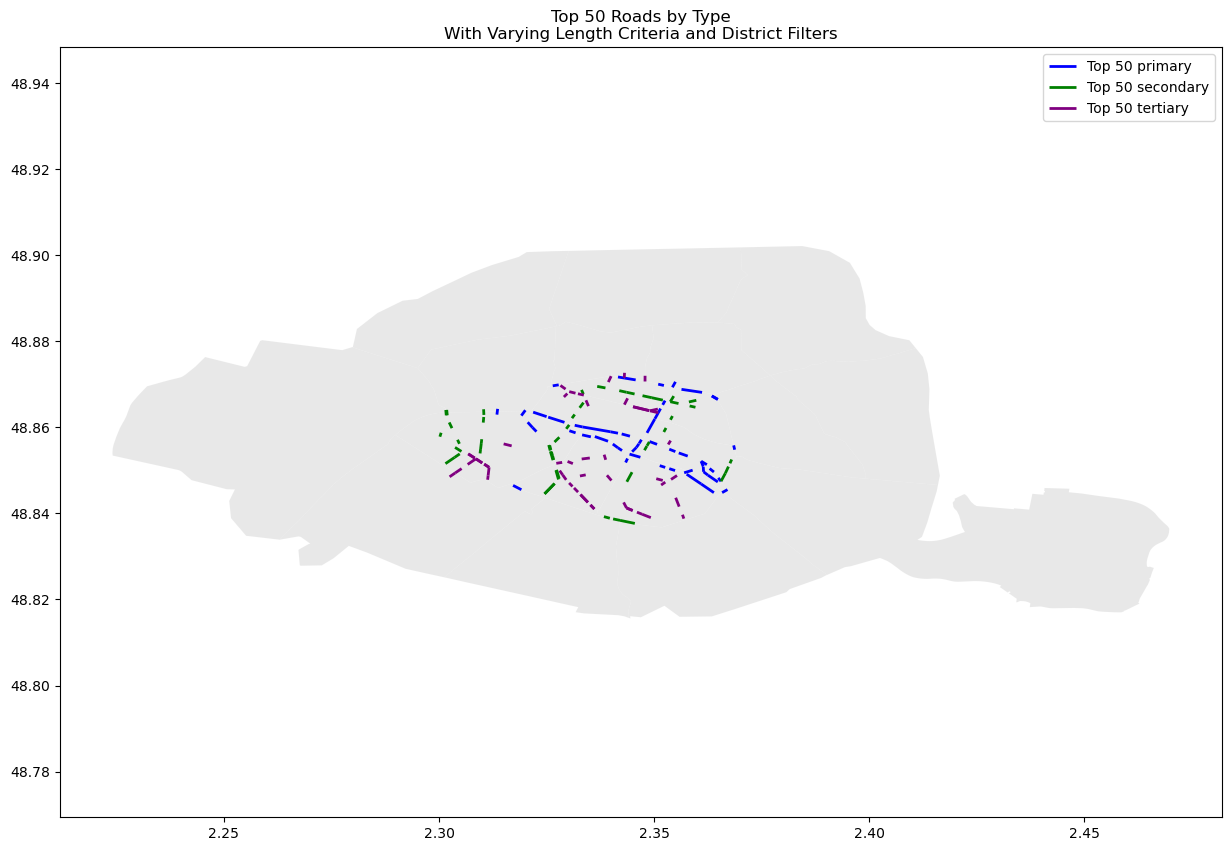

In [16]:
if is_for_general_pst_roads:
    road_criteria = {
        # 'trunk': {'min_length': 200, 'count': 50, 'district_filter': False},
        'primary': {'min_length': 200, 'count': 50, 'district_filter': False},
        'secondary': {'min_length': 100, 'count': 50, 'district_filter': False},
        'tertiary': {'min_length': 100, 'count': 50, 'district_filter': False},
        # 'residential': {'min_length': 100, 'count': 50, 'district_filter': True},
        # 'living_street': {'min_length': 50, 'count': 50, 'district_filter': True}
    }
else:
    road_criteria = {
        'primary': {'min_length': 100, 'count': 50, 'district_filter': True},
        'secondary': {'min_length': 100, 'count': 50, 'district_filter': True},
        'tertiary': {'min_length': 100, 'count': 50, 'district_filter': True},
    }

top_roads = {}

for road_type, criteria in road_criteria.items():
    filtered = gdf_edges_with_highway[gdf_edges_with_highway['osm:way:highway'] == road_type]
    
    # Convert length to numeric and apply length filter
    filtered['length'] = pd.to_numeric(filtered['length'], errors='coerce')
    filtered = filtered[filtered['length'] >= criteria['min_length']]
    
    # Apply district filter if needed
    if criteria['district_filter']:
        filtered = filtered[filtered['district'].apply(
            lambda x: any(float(d) in range(1, 8) for d in x if isinstance(d, (int, float)))
        )]
    
    # Get top N by traffic volume and sort by length
    top_n = filtered.nlargest(criteria['count'], 'vol_car_base_case')
    top_n_sorted = top_n.sort_values('length', ascending=False)
    
    # Create final GeoDataFrame
    top_n = gpd.GeoDataFrame(
        top_n_sorted[['id', 'osm:way:highway', 'vol_car_base_case', 'capacity_base_case', 'district', 'length', 'geometry']].copy(),
        geometry='geometry', 
        crs='EPSG:4326'
    )
    
    top_roads[road_type] = top_n
    print(f"\nTop {criteria['count']} {road_type} roads:")
    print(f"Minimum length: {criteria['min_length']}m")
    print(f"District filter: {'1-7' if criteria['district_filter'] else 'None'}")
    display(top_n)

# Create a map visualization
fig, ax = plt.subplots(figsize=(15, 10))

# Make sure districts are in the same CRS
if districts_gdf.crs != 'EPSG:4326':
    districts_gdf = districts_gdf.to_crs('EPSG:4326')

# Plot districts
districts_gdf.plot(ax=ax, alpha=0.5, color='lightgrey')

# Plot each road type with different colors
colors = {
    'primary': 'blue', 
    'secondary': 'green', 
    'tertiary': 'purple',
}
for road_type, color in colors.items():
    if not top_roads[road_type].empty:
        top_roads[road_type].plot(ax=ax, color=color, linewidth=2, label=f'Top 50 {road_type}')

plt.title('Top 50 Roads by Type\nWith Varying Length Criteria and District Filters')
plt.legend()
plt.axis('equal')
plt.show()

# Optional: Create a combined GeoDataFrame of all top roads for further analysis
# all_top_roads = pd.concat(top_roads.values())

In [17]:
selected_ids = {}
selected_roads_info = {}

for road_type, roads_df in top_roads.items():
    # Store the IDs in a list
    selected_ids[road_type] = roads_df['id'].tolist()
    
    # Store the full information in a DataFrame
    selected_roads_info[road_type] = roads_df[['id', 'length', 'vol_car_base_case', 'district']].copy()
    
# Combine all selected IDs into a single list
all_selected_ids = []
for ids in selected_ids.values():
    all_selected_ids.extend(ids)

print("All selected IDs combined:", all_selected_ids)

All selected IDs combined: ['599421', '387167', '450737', '379813', '379811', '587127', '155459', '604161', '7529', '711250', '679536', '535434', '179797', '432087', '355211', '66886', '275857', '538514', '642749', '525475', '458259', '494850', '283811', '362401', '233770', '233769', '565549', '599435', '89262', '592526', '275858', '7527', '325847', '499955', '693342', '588545', '432088', '270715', '7528', '566188', '218414', '668676', '633281', '497792', '397614', '656549', '294770', '245926', '592525', '270712', '342016', '509116', '470397', '363918', '582472', '79349', '331940', '404873', '710120', '710121', '189457', '143045', '448304', '275023', '533485', '394424', '414906', '148611', '142931', '142930', '157989', '331071', '520292', '666076', '189454', '531471', '2550', '62240', '430398', '394378', '342018', '394372', '621563', '436037', '621564', '110548', '275022', '414902', '394370', '459726', '176994', '582454', '21587', '377835', '394369', '237472', '386410', '404871', '2563

In [18]:
# Number of files per directory
files_per_dir = 1000

output_base_dir = base_dir + '/networks/'
# Ensure the base output directory exists
os.makedirs(output_base_dir, exist_ok=True)

# Create and save the networks
for i, id in enumerate(all_selected_ids):
    df_copy = gdf_edges_with_highway.copy()
    
    # Set policy_introduced based on the link ID instead of district
    df_copy['policy_introduced'] = (df_copy['id'] == id) & df_copy.apply(
        lambda row: 'car' in row['modes'], axis=1
    )
    
    # Modify capacity based on the policy_introduced condition
    df_copy.loc[df_copy['policy_introduced'], 'capacity'] = df_copy.loc[df_copy['policy_introduced'], 'capacity'] / 2

    # Determine the subdirectory based on the file index
    dir_index = (i // files_per_dir) + 1
    subdir_name = f"networks_{dir_index * files_per_dir}"
    output_dir = os.path.join(output_base_dir, subdir_name)
    
    # Create the subdirectory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    filename = f"network_link_{id}.xml.gz"
    
    # Convert the DataFrame to XML
    xml_tree = nio.dataframe_to_xml(df_copy, nodes_dict)
    
    # Write the XML to a compressed .gz file
    network_path = os.path.join(output_dir, filename)
    nio.write_xml_to_gz(xml_tree, network_path)

    # Clear the dataframe from memory
    del df_copy
    gc.collect()

# Example: Display the file paths of the saved files
output_files = [os.path.join(root, f) for root, _, files in os.walk(output_base_dir) for f in files]
print(output_files)

['../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts//networks/networks_1000/network_link_79349.xml.gz', '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts//networks/networks_1000/network_link_237472.xml.gz', '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts//networks/networks_1000/network_link_342018.xml.gz', '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts//networks/networks_1000/network_link_611774.xml.gz', '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_districts//networks/networks_1000/network_link_7529.xml.gz', '../../../../../data/pop_1pct_simulations/pop_1pct_cap_reduction/cap_reduction_on_single_roads/pst_roads_in_inner_dis